In [1]:
import os
import torch
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
from torchvision.io import decode_image
from torchvision.ops import nms
from torchvision import tv_tensors
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch import nn
import numpy as np
import re

In [2]:
torch.manual_seed(42)

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [4]:
weights = ResNet50_Weights.DEFAULT # weights = IMAGENET1K_V2
preprocess = weights.transforms()

In [5]:
# double input size tensor to have more spacial information and have less collision do to a greater number of cells
preprocess.resize_size[0] *= 2
preprocess.crop_size[0] *= 2
image_size = preprocess.crop_size[0]
print(preprocess)

ImageClassification(
    crop_size=[448]
    resize_size=[464]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [6]:
model = resnet50(weights=weights) 
for param in model.parameters():
    param.requires_grad = False # freeze the parameters of the model to only train the new layers for object detection first

## Build Dataloader loading the Custom Dataset

In [7]:
# Define the custom dataset and how to load the images and annotations => images and bounding boxes have to transformed equally

class CustomImageDataset(Dataset):
    def __init__(self, annotations_dir, img_dir, transform=None, img_transform=None):
        self.annotations_dir = annotations_dir
        self.annot_file_names = os.listdir(self.annotations_dir)
        self.img_dir = img_dir
        self.transform = transform  # v2 transformations which will be applied to image + label
        self.img_transform = img_transform # normal transformations (which will be also applied to validation + test) like resize, crop and normalization

    def __len__(self):
        return len(self.annot_file_names)

    def __getitem__(self, idx):
        file_name = self.annot_file_names[idx]
        # build the path to the annotation.txt and read the content
        annotation_path = os.path.join(self.annotations_dir, file_name)
        with open(annotation_path, "r") as f:
            try:
                objects = f.read().strip().split("\n")
                yolo_boxes = [[float(x.strip()) for x in obj.strip().split(" ")] for obj in objects]  # transform the string to a readable float label array
                # annotations as lines in txt-file with no header, each line containes 5 values seperated by a space: (class_id, x_center, y_center, width, height)
            except Exception as e:
                # no object/label for this image => file is empty, so use an empty label-list as the GT-annotation
                yolo_boxes = []
        # build the related path to the image and load it as a tensor
        img_path = os.path.join(self.img_dir, file_name).removesuffix("txt") + "jpg"
        image = decode_image(img_path)
        current_img_size = image.shape[-1] # image is a tensor with shape [C, H, W]
        # apply transformations if necessary
        if self.transform:
            if len(yolo_boxes) > 0: # only do the bounding box transformations if there are bounding boxes in the image
                raw_boxes = np.array([[cx, cy, w, h] for _, cx, cy, w, h in yolo_boxes]) 
                cxcywh_boxes = raw_boxes * current_img_size # cxcywh boxes is noted with absolute pixels, yolo with relative from [0, 1], so multiply by image size
                # => boxes are relative to the original image size, so we multiply by the current image size (instead of the target image size) to get the current absolute pixel values for the bounding box
                bboxes = tv_tensors.BoundingBoxes(cxcywh_boxes, format="CXCYWH", canvas_size=(current_img_size, current_img_size)) # canvas_size is the size of the original image
                image, transformed_bboxes = self.transform(image, bboxes) # transform both the image and the bounding boxes (only with v2 transformations which also affect the bounding boxes)
                relative_bboxes = transformed_bboxes / image.shape[-1] # scale back to relative bounding boxes ([0, 1]) for the yolo format => now relative to the new image size

                # to convert back to the yolo label format, the class labels have to be added again
                classes = torch.tensor([lbl[0] for lbl in yolo_boxes]).unsqueeze(1) # unsqueeze(1) to get a shape of [N, 1] => bboxes are shape [N, 4] so we can concatenate them to get a shape of [N, 5] for the yolo_boxes
                yolo_boxes = torch.cat((classes, relative_bboxes), dim=1) # dim=1 to concatenate along the columns 
            else:
                image = self.transform(image) # if there are no bounding boxes, just transform the image
        if self.img_transform:
            # preprocess transformations like normalize, which will not affect the label
            image = self.img_transform(image)
        return image, yolo_boxes

In [8]:
# Prepare Datasets

transform = v2.Compose([
    v2.RandomResizedCrop(image_size, (0.6, 1)),
    v2.RandomPerspective(0.75, 0.2),
    v2.ColorJitter(0.3, 0.2, 0.2, 0.1),
    v2.RandomGrayscale(0.1)
])

dataset_path = "../kaggle/Traffic_Sign/car"

test_dataset =  CustomImageDataset(
    annotations_dir=f"{dataset_path}/test/labels",
    img_dir=f"{dataset_path}/test/images",
    img_transform=preprocess
)

In [9]:
# load class names from yaml file

import yaml

with open(f"{dataset_path}/data.yaml", "r") as f:
    class_names = yaml.safe_load(f)["names"]

print("Num classes:", len(class_names))
print("Classes:", class_names)

Num classes: 15
Classes: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']


In [10]:
# Prepare Dataloader and define collate function to handle the different amounts of bounding boxes in each image

batch_size = 16 # 4x4 grid of predictions for test of the best model
num_workers = 0 # multiple workers will not work in a ipynb on macOS

def collate_fn(batch):
    return list(zip(*batch))
    # rearrange the batch into two tuples, each with len()=64: [(image_1, image_2, ...), (target_1, target_2, ...)]

test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collate_fn) # shuffle so we can use the same cell to predict different batches

In [11]:
def get_box_coords(box, image_size):
    class_id, x_c, y_c, w, h = box
    width = w * image_size
    height = h * image_size
    x1 = x_c * image_size - width / 2
    y1 = y_c * image_size - height / 2
    return (x1, y1, width, height)

## Changing Architecture to Object Detection instead of Classification

In [12]:
# building the model so the output is [64, 20, 14, 14] as we have 15 class probabilities + 4 coordinates + 1 objectness score with B = 1

class ObjectDetectionHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=2048, out_channels=2048, kernel_size=3, padding=1, bias=False)
        self.batchnorm1 = nn.BatchNorm2d(2048)
        self.conv2 = nn.Conv2d(in_channels=2048, out_channels=2048, kernel_size=3, padding=1, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(2048)
        self.outputmapping = nn.Conv2d(in_channels=2048, out_channels=20, kernel_size=1, bias=True)


    def forward(self, x):
        # extra Layer 1
        x = F.relu(self.batchnorm1(self.conv1(x)))
        # extra Layer 2
        x = F.relu(self.batchnorm2(self.conv2(x)))
        # mapping on desired output tensor shape
        x = self.outputmapping(x)
        return x
    
model = nn.Sequential(*list(model.children())[:-2]) # remove last two layers (avg_pool and fc) from the model 

model.add_module("Object Detection Head", ObjectDetectionHead())
model.to(device)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


## Prepare for prediction visualizaion

In [13]:
def yolo_to_bbox(yolo_box, img_size, map_size):
    # 64, 4, 14, 14
    cell_width = img_size / map_size

    # yolo_box[:, 0:2] is now only the x-offset and the y-offset feature map, but for GIoU we need the absolute coordinates of x1 and y1
    x_scale_tensor = torch.arange(0, map_size).expand(map_size, -1).to(device) # arange creates vector [0, ..., map_size-1], expand duplicates that to reach shape (map_size x map_size)
    y_scale_tensor = torch.arange(0, map_size).view((-1, 1)).expand(-1, map_size).to(device) # here we need to change the row vector to a "column vector", then expand "to the right"
    # calculate absolute x-coordinates => every column needs to be multiplied by 32 times the column index
    abs_x = cell_width * x_scale_tensor + yolo_box[:, 0] * cell_width 
    # calculate absolute y-coordinates => same as x-coordinate calculation but with 32 times the row index
    abs_y = cell_width * y_scale_tensor + yolo_box[:, 1] * cell_width
    
    # also convert relative height/width into absolute height/width
    abs_w = yolo_box[:, 2] * img_size
    abs_h = yolo_box[:, 3] * img_size

    x1 = abs_x - abs_w / 2
    y1 = abs_y - abs_h / 2
    x2 = abs_x + abs_w / 2
    y2 = abs_y + abs_h / 2

    bbox_tensor = torch.stack((x1, y1, x2, y2), dim=3)
    return bbox_tensor


In [14]:
def get_coords_from_pred(pred, threshold, image_size):
    class_maps = torch.softmax(pred[:, 5:], dim=1)
    max_probs, class_ids = torch.max(class_maps, dim=1)

    obj_map = torch.sigmoid(pred[:, 0])
    cell_confs = obj_map * max_probs # to get the total confidence for each cell, multiply the cell confidence with the class probability
    obj_mask = cell_confs > threshold
    obj_indices = torch.nonzero(obj_mask, as_tuple=True)
    # obj_indices list of length 3, each with 64 elements
    # first element are the batch indices, second element the y-coordinates (row) and third element the x-coordinates (column) of cells with objectness > 0.2

    obj_classes = class_ids[obj_indices] # because obj_indices is a tuple (batch_idx_tensor, y_coord_tensor, x_coord_tensor) we can index like class_ids[batch_idx_tensor, y_coord_tensor, x_coord_tensor]
    obj_conf = cell_confs[obj_indices] 

    loc_maps = torch.sigmoid(pred[:, 1:5])
    bbox_preds = yolo_to_bbox(loc_maps, img_size=image_size, map_size=pred.shape[-1])
    obj_bboxes = bbox_preds[obj_indices]

    return torch.stack(obj_indices, dim=1), obj_classes, obj_conf, obj_bboxes


In [15]:
def get_bbox_preds(batch_size, pred, threshold=0.25, image_size=image_size, nms_treshold=0.5):
    obj_indices, classes, confidences, bboxes = get_coords_from_pred(pred, threshold=threshold, image_size=image_size)

    nms_classes = []
    nms_bboxes = []
    nms_confidences = []

    for i in range(batch_size):
        # draw the boxes around the correct objects
        pred_mask = obj_indices[:, 0] == i
        obj_conf = confidences[pred_mask] # confidence scores of all predictions above the threshold for the current image
        obj_bboxes = bboxes[pred_mask]  # bbox predictions for object predictions above the threshold for the current image

        nms_indices = nms(obj_bboxes, obj_conf, iou_threshold=nms_treshold) # return the indices of the bbox-tensor (pred_loc) that are kept after nms
        nms_preds_indices = torch.nonzero(pred_mask)[nms_indices] # because the indices are relative to the pred_loc tensor, we calculate the absolute indices of the predictions (to index the ouput of get_coords_from_pred())

        nms_pred_classes = classes[nms_preds_indices] # all relevant classes after nms
        nms_pred_bboxes = obj_bboxes[nms_indices] # filter the bbox predictions to only keep the ones that are kept after nms
        nms_pred_conf = obj_conf[nms_indices]

        nms_classes.append(nms_pred_classes)
        nms_bboxes.append(nms_pred_bboxes)
        nms_confidences.append(nms_pred_conf)

    return nms_classes, nms_bboxes, nms_confidences

In [16]:
def visualize_bbox_preds(X, pred_classes, pred_bboxes, confidences, y=None, image_size=image_size):
    fig, axs = plt.subplots(4, 4, figsize=(15, 12))
    axs = axs.flatten()

    mean = torch.tensor(preprocess.mean).view(3, 1, 1) # because we have a tensor with shape [3, 244, 244], to process each channel seperately, we have to create a tensor with shape [3, 1, 1]
    std  = torch.tensor(preprocess.std).view(3, 1, 1)

    # visualize the first 16 images in the batch
    for i in range(16):
        # show the image with the classified label
        # X[i] is the tensor of the normalized image (with mean and std defined above) => with those parameters, we convert back to the normal image
        normal_image = X[i] * std + mean # revert the normalization process by multiplying with the standard deviation and adding the mean
        
        ax = axs[i]
        ax.imshow(normal_image.permute(1, 2, 0))
        ax.axis("off")
        
        
        # iterate over every prediction for the current image, get the coordinates and draw them into the current image
        for (cls, loc, conf) in zip(pred_classes[i], pred_bboxes[i], confidences[i]):
            x1, y1, x2, y2 = loc.cpu().detach().numpy()
            ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='red', linewidth=2))
            pred_class_idx = cls.item()
            ax.annotate(f"{class_names[pred_class_idx]} - {conf.item() * 100:.2f}%", 
                        xy=(x1, y1 - image_size * 0.02), 
                        color='black',
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'), 
                        fontsize=8)
        # correct prediction in green (if available)
        if y:
            x1_gt, y1_gt, w_gt, h_gt = get_box_coords(y[i][0], image_size)
            ax.add_patch(plt.Rectangle((x1_gt, y1_gt), w_gt, h_gt, fill=False, edgecolor='green', linewidth=2))

        # => torchvision.util.draw_bounding_boxes() can also draw bounding boxes in a given image

    plt.tight_layout()
    plt.show()


## Inference on best model

In [17]:
def load_best_model(model, file_name_start="TrafficSign_ObjDet_", folder="best_models"):
    # extracting the loss on the validation dataset with a regex expression, to be able identify the best model, which will be loaded
    saved_models = [model_dict for model_dict in os.listdir(folder) if model_dict.startswith(file_name_start)]
    # search for float in the name, get only the match-string and convert to float to be able to sort (+ argmax) afterwards to get the best model index in saved_models
    best_loss_idx = np.sort(np.array([float(re.search("[+-]?([0-9]*[.])?[0-9]+", model).group()) for model in saved_models])).argmax() 
    best_model_file = saved_models[best_loss_idx]
    print("Best model file:", best_model_file)
        
    best_model_dict = torch.load(f"{folder}/{best_model_file}", map_location=device)
    model.load_state_dict(best_model_dict)

In [18]:
load_best_model(model)

Best model file: TrafficSign_ObjDet_finetune_1.1770.pth


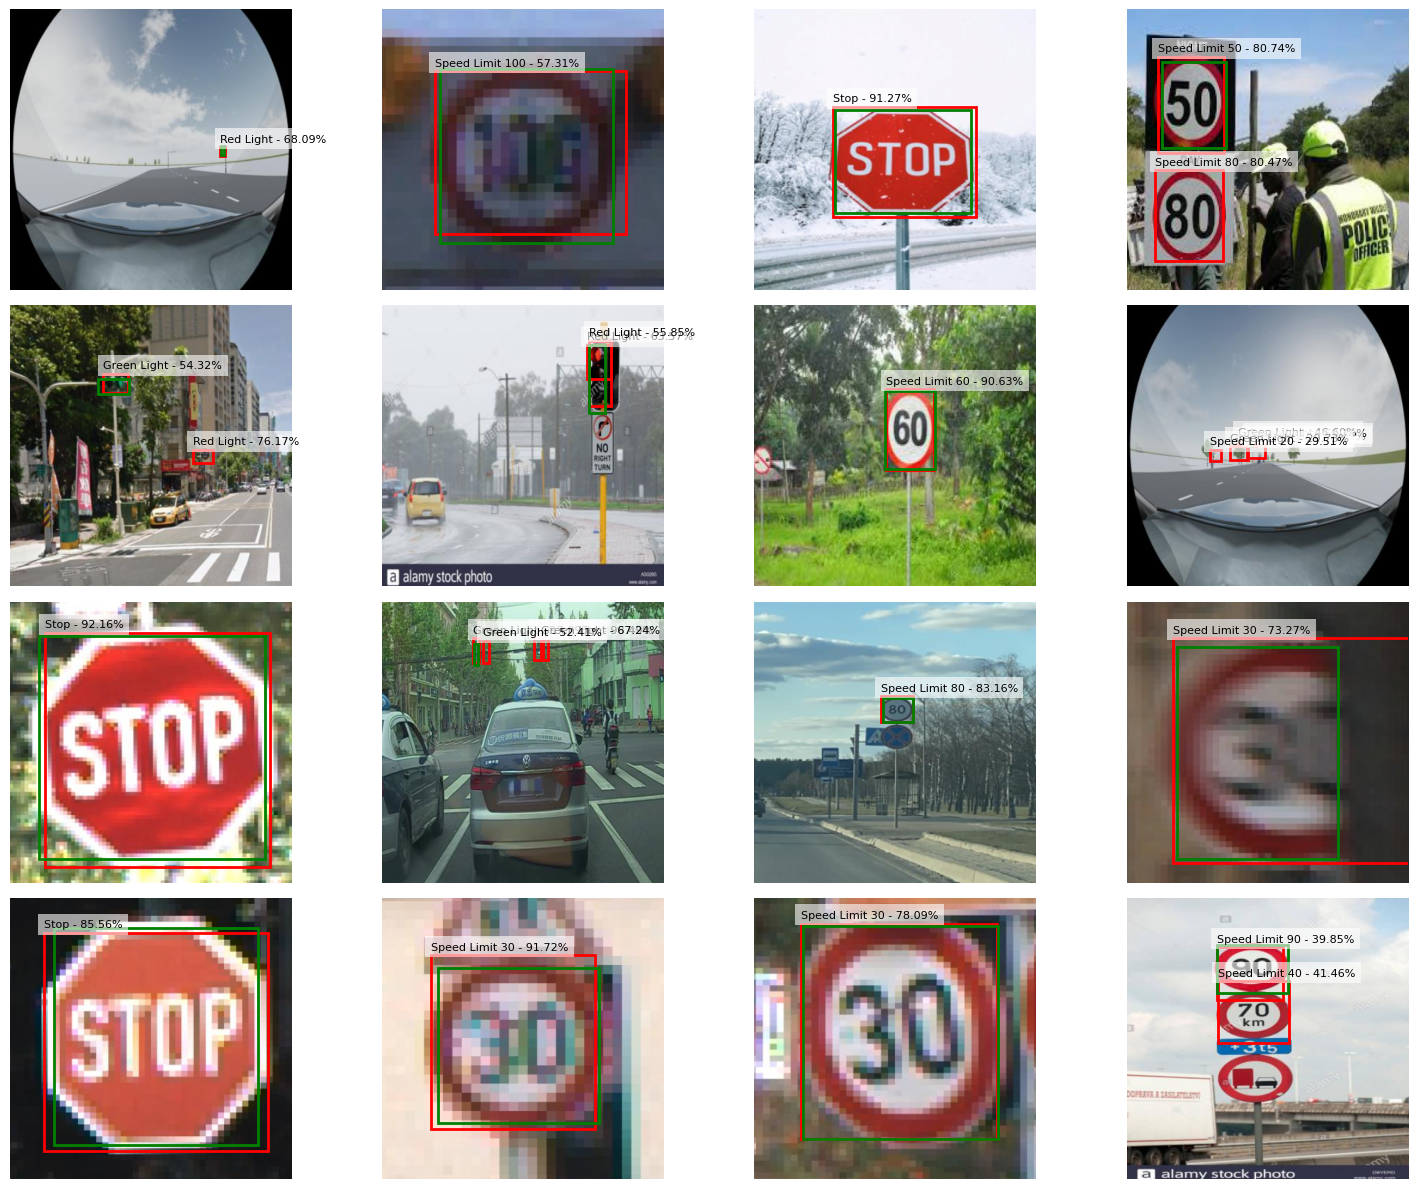

In [19]:
# compare the predicted bounding boxes with the GT bounding boxes
val_batch = next(iter(test_dataloader))
X, y = torch.stack(val_batch[0]).to(device), val_batch[1] # torch.stack() because the batch is a tuple of 64 images and 64 labels

pred = model(X)
pred_classes, pred_bboxes, pred_confidences = get_bbox_preds(batch_size=X.shape[0], pred=pred, threshold=0.25, image_size=image_size, nms_treshold=0.5)
visualize_bbox_preds(X.to('cpu'), pred_classes, pred_bboxes, pred_confidences, y=y, image_size=X.shape[-1])